In [1]:
import json, numpy as np, sympy as sp, matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import BinaryInteractions as KIJ

# Jupyter notebook display check; otherwise it falls back to print.
try:
    from IPython.display import display
    HAS_DISPLAY = True
except Exception:
    HAS_DISPLAY = False

# ============================================================
# STEP 2: LOAD THE 3 PAIRS FOR A TERNARY
# ============================================================

def _pair_folder_candidates(c1: str, c2: str):
    """Folders that might contain this pair."""
    return [f"{c1}_{c2}", f"{c2}_{c1}"]

def _select_model_block(d: dict, model: str):
    """
    Selects model block from JSON.
    model: 'constant', 'linear', 'quadratic', or 'best'
    Returns (model_used, deg, coeffs_desc)
    """

    available = [k for k in ("quadratic", "linear", "constant") if k in d]

    if model == "best":
        for m in ("quadratic", "linear", "constant"):
            if m in d:
                model = m
                break

    if model not in d:
        raise KeyError(f"Requested model='{model}' not found. Available: {available}")

    block = d[model]

    if model == "constant":
        deg = 0
        coeffs_desc = [float(block["mean"])]
    else:
        deg = int(block["deg"])
        coeffs_desc = [float(x) for x in block["coeffs"]]

    return model, deg, coeffs_desc


def load_pair_kij(root: Path, c1: str, c2: str, filename="KIJ.json", model="best"):
    """
    Loads pair KIJ.json using chosen model.
    """

    for folder in _pair_folder_candidates(c1, c2):
        path = root / folder / filename
        if path.exists():

            d = json.loads(path.read_text(encoding="utf-8"))

            model_used, deg, coeffs_desc = _select_model_block(d, model)
            coeffs_asc = coeffs_desc[::-1]

            return {
                "model": model_used,
                "deg": deg,
                "coeffs_desc": coeffs_desc,
                "coeffs_asc": coeffs_asc,
                "T_min": d.get("T_min", None),
                "T_max": d.get("T_max", None),
                "path": str(path),
            }

    raise FileNotFoundError(
        f"Missing {filename} for pair {c1}-{c2}"
    )

def load_ternary_pairs(root: Path, ternary, filename="KIJ.json", model_map=None):
    """
    model_map example:
        {
          ("CO","Ar"): "linear",
          ("CO2","Ar"): "constant",
          ("H2","Ar"): "linear"
        }

    If a pair not in model_map → default = "best"
    """

    if len(ternary) != 3:
        raise ValueError("ternary must have exactly 3 components")

    required_pairs = list(combinations(ternary, 2))
    pair_data = {}

    for a, b in required_pairs:

        # check both orderings in model_map
        chosen_model = "best"
        if model_map is not None:
            if (a, b) in model_map:
                chosen_model = model_map[(a, b)]
            elif (b, a) in model_map:
                chosen_model = model_map[(b, a)]

        pair_data[(a, b)] = load_pair_kij(
            root,
            a,
            b,
            filename=filename,
            model=chosen_model)

    return pair_data

# ============================================================
# STEP 3: BUILD POLYNOMIAL TENSOR A[k]
# ============================================================

def build_ternary_polynomial_tensor(ternary, pair_data):
    """
    Builds tensor A[k] where:
      K(T) = sum_k A[k] * T^k

    Returns:
      components (list[str]) length 3
      A (list[np.ndarray]) A[k] is 3x3
      max_deg (int)
    """
    components = list(ternary)
    idx = {c: i for i, c in enumerate(components)}

    max_deg = max(info["deg"] for info in pair_data.values())
    A = [np.zeros((3, 3), float) for _ in range(max_deg + 1)]

    for (c1, c2), info in pair_data.items():
        i, j = idx[c1], idx[c2]
        coeffs = info["coeffs_asc"]  # [a0, a1, ...]

        for k, ak in enumerate(coeffs):
            A[k][i, j] = ak
            A[k][j, i] = ak  # symmetric

    for Ak in A:
        np.fill_diagonal(Ak, 0.0)

    return components, A, max_deg

# ============================================================
# STEP 4: NUMERIC + SYMPY EVALUATION / DISPLAY
# ============================================================

def kij_numeric_matrix(T, A):
    """Evaluate K(T) = sum_k A[k] * T^k."""
    T = float(T)
    K = np.zeros_like(A[0])
    for k, Ak in enumerate(A):
        K += Ak * (T ** k)
    return K


def kij_sympy_matrix(A, digits=4):
    """
    Build Sympy matrix K(T) from A[k], rounding for display.
    """
    T = sp.Symbol("T", real=True)
    n = A[0].shape[0]
    K = sp.zeros(n, n)

    for k, Ak in enumerate(A):
        Ak_round = np.round(Ak, digits)
        K += sp.Matrix(Ak_round) * (T ** k)

    # enforce polynomial form
    K = K.applyfunc(lambda e: sp.Poly(sp.expand(e), T).as_expr())
    return T, K

def kij_sympy_equation_for_pair(components, A, pair, digits=4):
    """
    Return sympy expression for kij(T) for a given pair using A[k].
    """
    c1, c2 = pair
    idx = {c: i for i, c in enumerate(components)}
    i, j = idx[c1], idx[c2]

    T = sp.Symbol("T", real=True)
    expr = 0
    for k, Ak in enumerate(A):
        expr += round(float(Ak[i, j]), digits) * (T ** k)

    expr = sp.Poly(sp.expand(expr), T).as_expr()
    return T, expr

# ============================================================
# STEP 5: VALIDATION + WARNINGS
# ============================================================

def validate_ternary(pair_data, ternary):
    """
    Validates:
      - all 3 binary pairs exist
      - prints info about degrees (mixed is allowed, just warned)
    """
    required_pairs = list(combinations(ternary, 2))

    # if any key missing (shouldn't happen if load_ternary_pairs succeeded)
    for p in required_pairs:
        if p not in pair_data:
            raise FileNotFoundError(f"Missing pair data for {p}")

    degs = {p: pair_data[p]["deg"] for p in required_pairs}
    unique_degs = sorted(set(degs.values()))
    if len(unique_degs) > 1:
        print(f"Mixed polynomial degrees across pairs: {degs} (allowed)")
    else:
        print(f"All pairs use deg={unique_degs[0]}")

    return degs

def warn_if_T_outside_ranges(pair_data, ternary, T):
    """
    Prints warnings if T is outside [T_min, T_max] for any pair that has them.
    """
    T = float(T)
    required_pairs = list(combinations(ternary, 2))

    for a, b in required_pairs:
        info = pair_data[(a, b)]
        Tmin = info.get("T_min", None)
        Tmax = info.get("T_max", None)

        if Tmin is None or Tmax is None:
            print(f"No T_min/T_max for {a}-{b} ({info['path']})")
            continue

        if T < Tmin or T > Tmax:
            print(f" Warning: T={T} K outside [{Tmin}, {Tmax}] for pair {a}-{b} (file: {info['path']})")

def print_pair_summary(pair_data, ternary):
    required_pairs = list(combinations(ternary, 2))
    print("\nPair summary (from KIJ.json):")
    for a, b in required_pairs:
        info = pair_data[(a, b)]
        print(f"  {a}-{b}: deg={info['deg']}, coeffs={info['coeffs_desc']}, file={info['path']}")
        
# ============================================================
# STEP 6: KIJ vs T PLOT with legends
# ============================================================

def show_pair_plot(root: Path, c1: str, c2: str, filename="KIJ.json", plot_key="kij_vs_T"):
    """
    Displays a stored plot from a pair's KIJ.json.
    plot_key: 'kij_vs_T' or 'legend'
    """
    for folder in _pair_folder_candidates(c1, c2):
        path = root / folder / filename
        if path.exists():
            d = json.loads(path.read_text(encoding="utf-8"))

            if "plots" not in d:
                raise KeyError(f"No 'plots' key found in {path}")
            if plot_key not in d["plots"]:
                raise KeyError(f"Plot '{plot_key}' not found. Available: {list(d['plots'].keys())}")

            img = mpimg.imread(io.BytesIO(base64.b64decode(d["plots"][plot_key])))
            fig, ax = plt.subplots()
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{c1}-{c2} | {plot_key}")
            plt.tight_layout()
            plt.show()
            return

    raise FileNotFoundError(f"Missing {filename} for pair {c1}-{c2}")

def show_all_pair_plots(root: Path, c1: str, c2: str, filename="KIJ.json"):
    """
    Displays all stored plots from a pair's KIJ.json.
    """
    for folder in _pair_folder_candidates(c1, c2):
        path = root / folder / filename
        if path.exists():
            d = json.loads(path.read_text(encoding="utf-8"))

            if "plots" not in d:
                raise KeyError(f"No 'plots' key found in {path}")

            for plot_key, b64_str in d["plots"].items():
                img = mpimg.imread(io.BytesIO(base64.b64decode(b64_str)))
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.axis("off")
                ax.set_title(f"{c1}-{c2} | {plot_key}")
                plt.tight_layout()
                plt.show()
            return

    raise FileNotFoundError(f"Missing {filename} for pair {c1}-{c2}")


In [2]:
# -------------------------
# USER SETTINGS
# -------------------------
ternary = ["CO2", "H2", "Ar"]

model_map = {
    ("CO2", "Ar"): "constant",
    ("H2",  "Ar"): "linear",
    ("CO2", "H2"): "linear",}

T_eval = 300.0
digits = 4

# -------------------------
# LOAD + BUILD
# -------------------------
pair_data = load_ternary_pairs(Path("."), ternary, model_map=model_map)

print_pair_summary(pair_data, ternary)
validate_ternary(pair_data, ternary)
warn_if_T_outside_ranges(pair_data, ternary, T_eval)

components, A, max_deg = build_ternary_polynomial_tensor(ternary, pair_data)

# -------------------------
# NUMERIC MATRIX AT T_eval
# -------------------------
K_eval = kij_numeric_matrix(T_eval, A)
print(f"\nK({T_eval} K) =")
print(K_eval)

# -------------------------
# SYMBOLIC MATRIX K(T)
# -------------------------
T, Ksym = kij_sympy_matrix(A, digits=digits)
print("\nSymbolic K(T):")
if HAS_DISPLAY:
    display(Ksym)
else:
    sp.init_printing(use_unicode=True)
    print(sp.pretty(Ksym))

# -------------------------
# SYMBOLIC EQUATIONS FOR ALL 3 PAIRS
# -------------------------
print("\nPair equations:")
for pair in combinations(components, 2):
    Tpair, expr = kij_sympy_equation_for_pair(components, A, pair, digits=digits)
    ksym = sp.Function(f"k_{{{pair[0]},{pair[1]}}}")
    eq = sp.Eq(ksym(Tpair), expr)

    if HAS_DISPLAY:
        display(eq)
    else:
        print(sp.pretty(eq))


Pair summary (from KIJ.json):
  CO2-H2: deg=1, coeffs=[-0.0009898251246954924, 0.29299248107831705], file=CO2_H2/KIJ.json
  CO2-Ar: deg=0, coeffs=[0.03481294797303504], file=CO2_Ar/KIJ.json
  H2-Ar: deg=1, coeffs=[0.00021420765118792114, 0.15566424528663514], file=Ar_H2/KIJ.json
Mixed polynomial degrees across pairs: {('CO2', 'H2'): 1, ('CO2', 'Ar'): 0, ('H2', 'Ar'): 1} (allowed)

K(300.0 K) =
[[ 0.         -0.00395506  0.03481295]
 [-0.00395506  0.          0.21992654]
 [ 0.03481295  0.21992654  0.        ]]

Symbolic K(T):


Matrix([
[              0,   0.293 - 0.001*T,            0.0348],
[0.293 - 0.001*T,                 0, 0.0002*T + 0.1557],
[         0.0348, 0.0002*T + 0.1557,                 0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0.293 - 0.001*T)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0.0002*T + 0.1557)

In [3]:
builder = KIJ.KIJMatrixBuilder(root=".", kij_filename="KIJ.json", verbose = True)
ternary = ["CO2", "H2", "Ar"]
KIJ_map = {
    ("CO2", "Ar"): "constant",
    ("H2",  "Ar"): "linear",
    ("CO2", "H2"): "linear",}

components, A, Knum, (T, Ksym), pair_data = builder.build_and_display(
    ternary=ternary,
    model_map=KIJ_map,
    T_eval=300.0,     # numeric evaluation temperature
    digits=4,         # rounding for sympy display
    show_matrix=True,
    show_pair_equations=True,
)


Pair summary (from KIJ.json):
  CO2-H2: model=linear, deg=1, coeffs=[-0.0009898251246954924, 0.29299248107831705], file=CO2_H2/KIJ.json
  CO2-Ar: model=constant, deg=0, coeffs=[0.03481294797303504], file=CO2_Ar/KIJ.json
  H2-Ar: model=linear, deg=1, coeffs=[0.00021420765118792114, 0.15566424528663514], file=Ar_H2/KIJ.json
Mixed polynomial degrees across pairs: {('CO2', 'H2'): 1, ('CO2', 'Ar'): 0, ('H2', 'Ar'): 1} (allowed)

K(300.0 K) =
[[ 0.         -0.00395506  0.03481295]
 [-0.00395506  0.          0.21992654]
 [ 0.03481295  0.21992654  0.        ]]

Symbolic K(T) matrix:


Matrix([
[              0,   0.293 - 0.001*T,            0.0348],
[0.293 - 0.001*T,                 0, 0.0002*T + 0.1557],
[         0.0348, 0.0002*T + 0.1557,                 0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0.293 - 0.001*T)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0.0002*T + 0.1557)

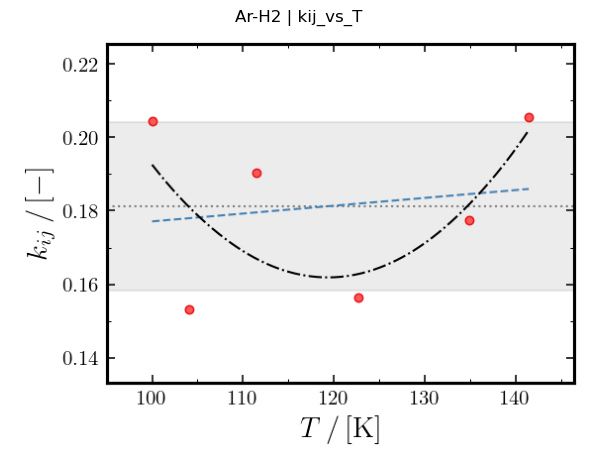

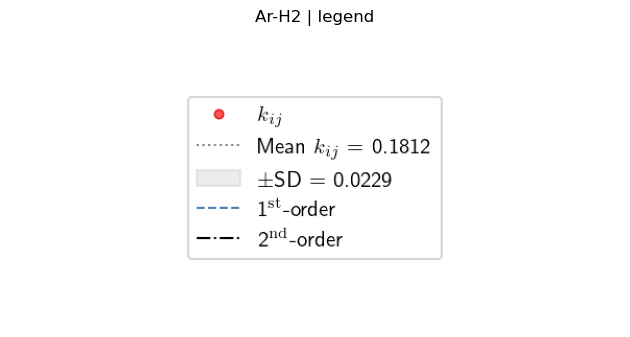

In [6]:
builder.show_pair_plot("Ar", "H2", mode="all")